# Q3 Linear Regression Assumption Checks

Question: **How long does it take noise complaints to be resolved, and do some regions resolve them faster?**

This analysis estimates log-resolution time and evaluates OLS assumptions (linearity, variance stability, independence, and normality) on the cleaned complaint sample.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

## 1. Paths and safe loading settings

The CSV is processed in chunks and sampled to keep memory use stable while preserving enough rows for diagnostics.

In [3]:
DATA_PATH = Path("data/311_data.csv")

# Memory-safety knobs. Increase slowly if this runs comfortably.
CHUNKSIZE = 100_000
MAX_FILTERED_ROWS = 120_000      # max closed noise-complaint rows kept before target cleanup
MAX_MODEL_ROWS = 45_000
PLOT_N = 6_000                   # max points used in LOWESS/residual plots
RANDOM_SEED = 3120

# Set to an integer for quick debugging, e.g. 5 or 10. Set None for normal use.
MAX_CHUNKS = None

DATA_PATH

PosixPath('data/311_data.csv')

## 2. Read only the columns we need

In [4]:
header = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
print(f"Number of columns in CSV: {len(header)}")

COL_CREATED = "Created Date"
COL_CLOSED = "Closed Date"
COL_PROBLEM = "Problem (formerly Complaint Type)"
COL_DETAIL = "Problem Detail (formerly Descriptor)"
COL_ZIP = "Incident Zip"
COL_BOROUGH = "Borough"
COL_AGENCY = "Agency"
COL_STATUS = "Status"
COL_ADDRESS = "Incident Address"
COL_LOCATION_TYPE = "Location Type"
COL_LAT = "Latitude"
COL_LON = "Longitude"

candidate_cols = [
    COL_CREATED, COL_CLOSED, COL_PROBLEM, COL_DETAIL,
    COL_ZIP, COL_BOROUGH, COL_AGENCY, COL_STATUS,
    COL_ADDRESS, COL_LOCATION_TYPE, COL_LAT, COL_LON,
]

usecols = [c for c in candidate_cols if c in header]
missing_cols = [c for c in candidate_cols if c not in header]

print("Reading these columns:")
for c in usecols:
    print("  -", c)

if missing_cols:
    print("\nMissing optional columns:")
    for c in missing_cols:
        print("  -", c)

Number of columns in CSV: 44
Reading these columns:
  - Created Date
  - Closed Date
  - Problem (formerly Complaint Type)
  - Problem Detail (formerly Descriptor)
  - Incident Zip
  - Borough
  - Agency
  - Status
  - Incident Address
  - Location Type
  - Latitude
  - Longitude


## 3. Chunked loading and target construction

Target:

$$
\text{delay\_hours} = \frac{\text{Closed Date} - \text{Created Date}}{3600}
$$

We filter to closed noise complaints only. Unresolved cases are a different modeling problem because their true final delay is not observed yet.

In [5]:
def parse_311_datetime(s):
    return pd.to_datetime(s, errors="coerce")


def prepare_chunk(chunk):
    chunk = chunk.copy()

    chunk["Created Date"] = parse_311_datetime(chunk[COL_CREATED])
    chunk["Closed Date"] = parse_311_datetime(chunk[COL_CLOSED])

    chunk["created_dt"] = chunk["Created Date"]
    chunk["closed_dt"] = chunk["Closed Date"]

    chunk["resolution_hours"] = (chunk["Closed Date"] - chunk["Created Date"]).dt.total_seconds() / 3600
    chunk["resolution_days"] = chunk["resolution_hours"] / 24

    chunk["is_resolved"] = (
        chunk["Closed Date"].notna()
        & chunk["Created Date"].notna()
        & (chunk["resolution_hours"] >= 0)
    )

    out = chunk.loc[chunk["is_resolved"]].copy()
    return out


def bounded_sample_append(parts, new_part, max_rows, random_state):
    parts.append(new_part)
    combined = pd.concat(parts, ignore_index=True)

    if len(combined) > max_rows:
        combined = combined.sample(n=max_rows, random_state=random_state).reset_index(drop=True)

    return [combined]


parts = []
filtered_seen = 0

for i, chunk in enumerate(pd.read_csv(DATA_PATH, usecols=usecols, chunksize=CHUNKSIZE, low_memory=False), start=1):
    filtered = prepare_chunk(chunk)
    filtered_seen += len(filtered)

    if len(filtered) > 0:
        parts = bounded_sample_append(parts, filtered, MAX_FILTERED_ROWS, RANDOM_SEED + i)

    if i % 10 == 0:
        kept = sum(len(p) for p in parts)
        print(f"processed chunks: {i:,}, closed noise rows seen: {filtered_seen:,}, rows kept: {kept:,}")

    if MAX_CHUNKS is not None and i >= MAX_CHUNKS:
        break

    if filtered_seen >= MAX_FILTERED_ROWS * 3 and sum(len(p) for p in parts) >= MAX_FILTERED_ROWS:
        # Enough data for a stable regression sample; this avoids unnecessarily scanning the full 4.5GB file.
        break

if not parts:
    raise ValueError("No closed noise complaints were found. Check column names and filters.")

df_raw = pd.concat(parts, ignore_index=True)

print("\nFinal sampled shape:", df_raw.shape)
print("Total filtered closed noise rows seen while scanning:", f"{filtered_seen:,}")
print("Approx sample memory MB:", round(df_raw.memory_usage(deep=True).sum() / 1e6, 2))
display(df_raw.head(3).T)


Final sampled shape: (120000, 17)
Total filtered closed noise rows seen while scanning: 382,235
Approx sample memory MB: 25.55


,0,1,2
Created Date,2025-12-03 05:52:45,2025-12-02 11:30:24,2025-12-01 16:42:32
Closed Date,2025-12-03 07:01:11,2025-12-05 14:09:34,2025-12-19 06:45:59
Agency,NYPD,DOHMH,HPD
Problem (formerly Complaint Type),Illegal Parking,Rodent,PAINT/PLASTER
Problem Detail (formerly Descriptor),Double Parked Blocking Vehicle,Rat Sighting,WALL
Location Type,Street/Sidewalk,3+ Family Apt. Building,RESIDENTIAL BUILDING
Incident Zip,10467.0,11211.0,10458.0
Incident Address,3228 DECATUR AVENUE,68 RICHARDSON STREET,2962 DECATUR AVENUE
Status,Closed,Closed,Closed
Borough,BRONX,BROOKLYN,BRONX


## 4. Target cleanup and basic plots

Because response time is very right-skewed, we model `log1p(delay_hours)`. We also cap the extreme upper tail for the assumption-checking regression, since very large operational outliers can dominate OLS.

Rows after resolved filter: 120,000
Rows after positive-duration filter: 118,714
Resolution cap: 588.391 hours
Rows used for modeling: 45,000


,count,mean,std,min,25%,50%,75%,90%,95%,max
resolution_hours,45000.0,98.612990,269.999343,0.000278,1.311389,8.194028,54.785764,211.091667,598.950625,2262.853889
resolution_hours_capped,45000.0,70.264228,145.717626,0.000278,1.311389,8.194028,54.785764,211.091667,588.390833,588.390833
log_resolution_hours,45000.0,2.569591,1.892810,0.000278,0.837849,2.218554,4.021519,5.357019,6.379090,6.379090


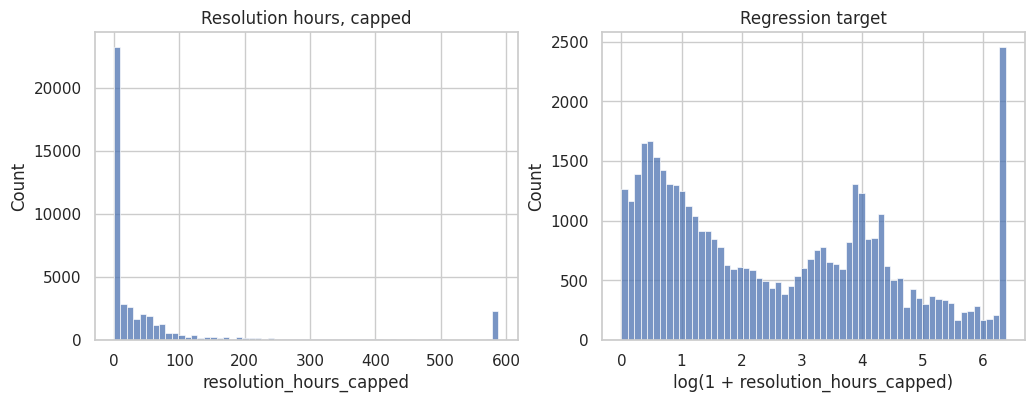

In [6]:
TARGET_UPPER_QUANTILE = 0.95

resolved = df_raw[df_raw["is_resolved"]].copy()
ml_df = resolved[resolved["resolution_hours"] > 0].copy()

cap = ml_df["resolution_hours"].quantile(TARGET_UPPER_QUANTILE)
ml_df["resolution_hours_capped"] = ml_df["resolution_hours"].clip(upper=cap)
ml_df["log_resolution_hours"] = np.log1p(ml_df["resolution_hours_capped"])

# Keep legacy target name used downstream by existing diagnostics.
ml_df["delay_hours"] = ml_df["resolution_hours_capped"]
ml_df["log_delay"] = ml_df["log_resolution_hours"]

df_model = ml_df.copy()
if len(df_model) > MAX_MODEL_ROWS:
    df_model = df_model.sample(n=MAX_MODEL_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

print("Rows after resolved filter:", f"{len(resolved):,}")
print("Rows after positive-duration filter:", f"{len(ml_df):,}")
print("Resolution cap:", round(cap, 3), "hours")
print("Rows used for modeling:", f"{len(df_model):,}")
display(df_model[["resolution_hours", "resolution_hours_capped", "log_resolution_hours"]].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).T)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_model["resolution_hours_capped"], bins=60, ax=ax[0])
ax[0].set_title("Resolution hours, capped")
ax[0].set_xlabel("resolution_hours_capped")

sns.histplot(df_model["log_resolution_hours"], bins=60, ax=ax[1])
ax[1].set_title("Regression target")
ax[1].set_xlabel("log(1 + resolution_hours_capped)")
plt.show()

## 5. Feature engineering helpers

In [7]:
def clean_category(s):
    return s.astype("string").fillna("Missing").astype(str).str.strip().replace("", "Missing")


def clean_zip(s):
    numeric_zip = pd.to_numeric(s, errors="coerce").astype("Int64").astype("string")
    return numeric_zip.fillna("Missing")


def top_or_other(s, max_levels):
    s = clean_category(s)
    top = s.value_counts(dropna=False).head(max_levels).index
    return s.where(s.isin(top), "Other")


def add_past_count(df, group_col, days, out_col):
    # Counts prior complaints within the loaded sample, not the entire 4.5GB file.
    out = pd.Series(0.0, index=df.index)
    if group_col not in df.columns:
        df[out_col] = out
        return df

    tmp = df[["created_dt", group_col]].dropna(subset=["created_dt"]).copy()
    tmp["_group"] = clean_category(tmp[group_col])
    window_ns = pd.Timedelta(days=days).value

    for _, g in tmp.groupby("_group", sort=False):
        g = g.sort_values("created_dt")
        times = g["created_dt"].astype("int64").to_numpy()
        left = np.searchsorted(times, times - window_ns, side="left")
        counts = np.arange(len(times)) - left
        out.loc[g.index] = counts

    df[out_col] = out
    return df


def add_engineered_columns(df):
    df = df.copy()

    df["descriptor"] = clean_category(df[COL_DETAIL]) if COL_DETAIL in df.columns else "Missing"
    df = df[~df["descriptor"].isin(["Other", "NYPD", "News Gathering"])].copy()

    descriptor_top = top_or_other(df["descriptor"], max_levels=20)
    location_raw = clean_category(df[COL_LOCATION_TYPE]) if COL_LOCATION_TYPE in df.columns else pd.Series("Missing", index=df.index)

    df["descriptor_top"] = descriptor_top.astype(str)
    df["location_type_top"] = top_or_other(location_raw, max_levels=10).astype(str)
    df["borough_clean"] = clean_category(df[COL_BOROUGH]) if COL_BOROUGH in df.columns else "Missing"

    df["created_hour"] = df["created_dt"].dt.hour.astype(float)
    df["created_dayofweek"] = df["created_dt"].dt.day_name().astype(str)
    df["created_month"] = df["created_dt"].dt.month.astype(float)

    df["hour"] = df["created_hour"]
    df["hour_sin"] = np.sin(2 * np.pi * df["created_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["created_hour"] / 24)
    df["day_of_week"] = df["created_dayofweek"]
    df["month"] = df["created_month"].astype("Int64").astype("string")
    df["time_bucket"] = pd.cut(
        df["created_hour"],
        bins=[-1, 5, 11, 16, 20, 23],
        labels=["late_night", "morning", "afternoon", "evening", "night"],
    ).astype(str)

    return df

## 6. Feature map

In [8]:
FEATURE_MAP = {
    "descriptor_top": {
        "enabled": True,
        "type": "cat",
        "columns": ["descriptor_top"],
        "max_levels": 20,
    },
    "borough_clean": {
        "enabled": True,
        "type": "cat",
        "columns": ["borough_clean"],
        "max_levels": 10,
    },
    "location_type_top": {
        "enabled": True,
        "type": "cat",
        "columns": ["location_type_top"],
        "max_levels": 10,
    },
    "created_dayofweek": {
        "enabled": True,
        "type": "cat",
        "columns": ["created_dayofweek"],
        "max_levels": 7,
    },
    "created_hour": {
        "enabled": True,
        "type": "num",
        "columns": ["created_hour"],
    },
    "created_month": {
        "enabled": True,
        "type": "num",
        "columns": ["created_month"],
    },
    "hour_cyclic": {
        "enabled": True,
        "type": "num",
        "columns": ["hour_sin", "hour_cos"],
    },
}

## 7. Build the design matrix

In [9]:
def make_design_matrix(df, feature_map):
    X_parts = []
    feature_group_columns = {}
    raw_feature_frame = pd.DataFrame(index=df.index)

    for group_name, spec in feature_map.items():
        if not spec.get("enabled", True):
            continue

        cols = spec["columns"]
        missing = [c for c in cols if c not in df.columns]
        if missing:
            print(f"Skipping {group_name}; missing columns: {missing}")
            continue

        if spec["type"] == "num":
            block = df[cols].apply(pd.to_numeric, errors="coerce")
            block = block.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
            block.columns = cols

        elif spec["type"] == "cat":
            if len(cols) != 1:
                raise ValueError("Categorical feature groups should use exactly one column.")

            col = cols[0]
            cleaned = top_or_other(df[col], max_levels=spec.get("max_levels", 25))
            raw_feature_frame[col] = cleaned
            block = pd.get_dummies(cleaned, prefix=group_name, drop_first=True, dtype=float)

        else:
            raise ValueError(f"Unknown feature type: {spec['type']}")

        X_parts.append(block)
        feature_group_columns[group_name] = list(block.columns)

        for c in cols:
            if c not in raw_feature_frame.columns:
                raw_feature_frame[c] = df[c]

    if not X_parts:
        raise ValueError("No features enabled.")

    X = pd.concat(X_parts, axis=1)
    X = sm.add_constant(X, has_constant="add")
    return X, raw_feature_frame, feature_group_columns


df_feat = add_engineered_columns(df_model)
X, feature_frame, feature_group_columns = make_design_matrix(df_feat, FEATURE_MAP)
y = df_feat["log_delay"].astype(float)

print("X shape:", X.shape)
print("Enabled feature groups:")
for group, cols in feature_group_columns.items():
    print(f"  {group}: {len(cols)} column(s)")

display(X.head())

X shape: (44983, 44)
Enabled feature groups:
  descriptor_top: 19 column(s)
  borough_clean: 5 column(s)
  location_type_top: 9 column(s)
  created_dayofweek: 6 column(s)
  created_hour: 1 column(s)
  created_month: 1 column(s)
  hour_cyclic: 2 column(s)


,const,descriptor_top_Banging/Pounding,descriptor_top_Blocked Crosswalk,descriptor_top_Blocked Hydrant,descriptor_top_Blocked Sidewalk,descriptor_top_Commercial Overnight Parking,descriptor_top_Derelict Vehicles,descriptor_top_ENTIRE BUILDING,descriptor_top_Loud Music/Party,descriptor_top_Loud Talking,descriptor_top_Missing,descriptor_top_No Access,descriptor_top_Other,descriptor_top_PESTS,descriptor_top_Partial Access,descriptor_top_Posted Parking Sign Violation,descriptor_top_Pothole,descriptor_top_Sidewalk,descriptor_top_Trash,descriptor_top_With License Plate,borough_clean_BROOKLYN,borough_clean_MANHATTAN,borough_clean_QUEENS,borough_clean_STATEN ISLAND,borough_clean_Unspecified,location_type_top_Club/Bar/Restaurant,location_type_top_Missing,location_type_top_Other,location_type_top_RESIDENTIAL BUILDING,location_type_top_Residential Building/House,location_type_top_Sidewalk,location_type_top_Store/Commercial,location_type_top_Street,location_type_top_Street/Sidewalk,created_dayofweek_Monday,created_dayofweek_Saturday,created_dayofweek_Sunday,created_dayofweek_Thursday,created_dayofweek_Tuesday,created_dayofweek_Wednesday,created_hour,created_month,hour_sin,hour_cos
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,11.0,0.866025,0.500000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.0,12.0,-0.866025,-0.500000
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,17.0,11.0,-0.965926,-0.258819
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,11.0,0.707107,-0.707107
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,12.0,0.707107,-0.707107


## 8. Fit OLS

Compare standard and robust standard errors to see whether heteroskedasticity materially changes inference.

In [10]:
model = sm.OLS(y, X)
results = model.fit()
robust_results = model.fit(cov_type="HC3")

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              log_delay   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     2203.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        17:56:10   Log-Likelihood:                -67026.
No. Observations:               44983   AIC:                         1.341e+05
Df Residuals:                   44939   BIC:                         1.345e+05
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [11]:
print("Regular OLS R^2:", round(results.rsquared, 4))
print("Regular OLS adjusted R^2:", round(results.rsquared_adj, 4))
print("\nRobust-standard-error version of the same coefficient estimates:")
print(robust_results.summary())

Regular OLS R^2: 0.6783
Regular OLS adjusted R^2: 0.678

Robust-standard-error version of the same coefficient estimates:
                            OLS Regression Results                            
Dep. Variable:              log_delay   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     3319.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        17:56:10   Log-Likelihood:                -67026.
No. Observations:               44983   AIC:                         1.341e+05
Df Residuals:                   44939   BIC:                         1.345e+05
Df Model:                          43                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|

## 9. Quick train/test check

This is not one of the classical assumptions, but it helps avoid improving only the in-sample fit.

In [12]:
ordered_idx = df_feat.sort_values("created_dt").index.to_numpy()
split = int(0.80 * len(ordered_idx))
train_idx = ordered_idx[:split]
test_idx = ordered_idx[split:]

train_results = sm.OLS(y.loc[train_idx], X.loc[train_idx]).fit()
test_pred = train_results.predict(X.loc[test_idx])

print("Train R^2:", round(train_results.rsquared, 4))
print("Test R^2:", round(r2_score(y.loc[test_idx], test_pred), 4))
print("Test RMSE on log scale:", round(mean_squared_error(y.loc[test_idx], test_pred), 4))
print("Test MAE on log scale:", round(mean_absolute_error(y.loc[test_idx], test_pred), 4))

Train R^2: 0.6851
Test R^2: 0.6483
Test RMSE on log scale: 1.2814
Test MAE on log scale: 0.8273


## 10. Save fitted values and residuals

In [13]:
df_diag = df_feat.copy()
df_diag["fitted"] = results.fittedvalues
df_diag["resid"] = results.resid
infl = results.get_influence()
df_diag["std_resid"] = infl.resid_studentized_internal

display(df_diag[["delay_hours", "log_delay", "fitted", "resid", "std_resid"]].head())

,delay_hours,log_delay,fitted,resid,std_resid
0,3.560556,1.517444,0.758126,0.759318,0.707071
1,67.731389,4.230206,3.788922,0.441284,0.410915
2,9.240833,2.326383,1.078997,1.247386,1.161444
3,1.468611,0.903656,0.937445,-0.033790,-0.031462
4,89.737500,4.507971,3.611346,0.896625,0.834925


## 11. Linearity checks using LOWESS residual plots

LOWESS curves near zero support linearity; persistent curvature indicates likely misspecification.

/home/kreshank/envs/ml/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


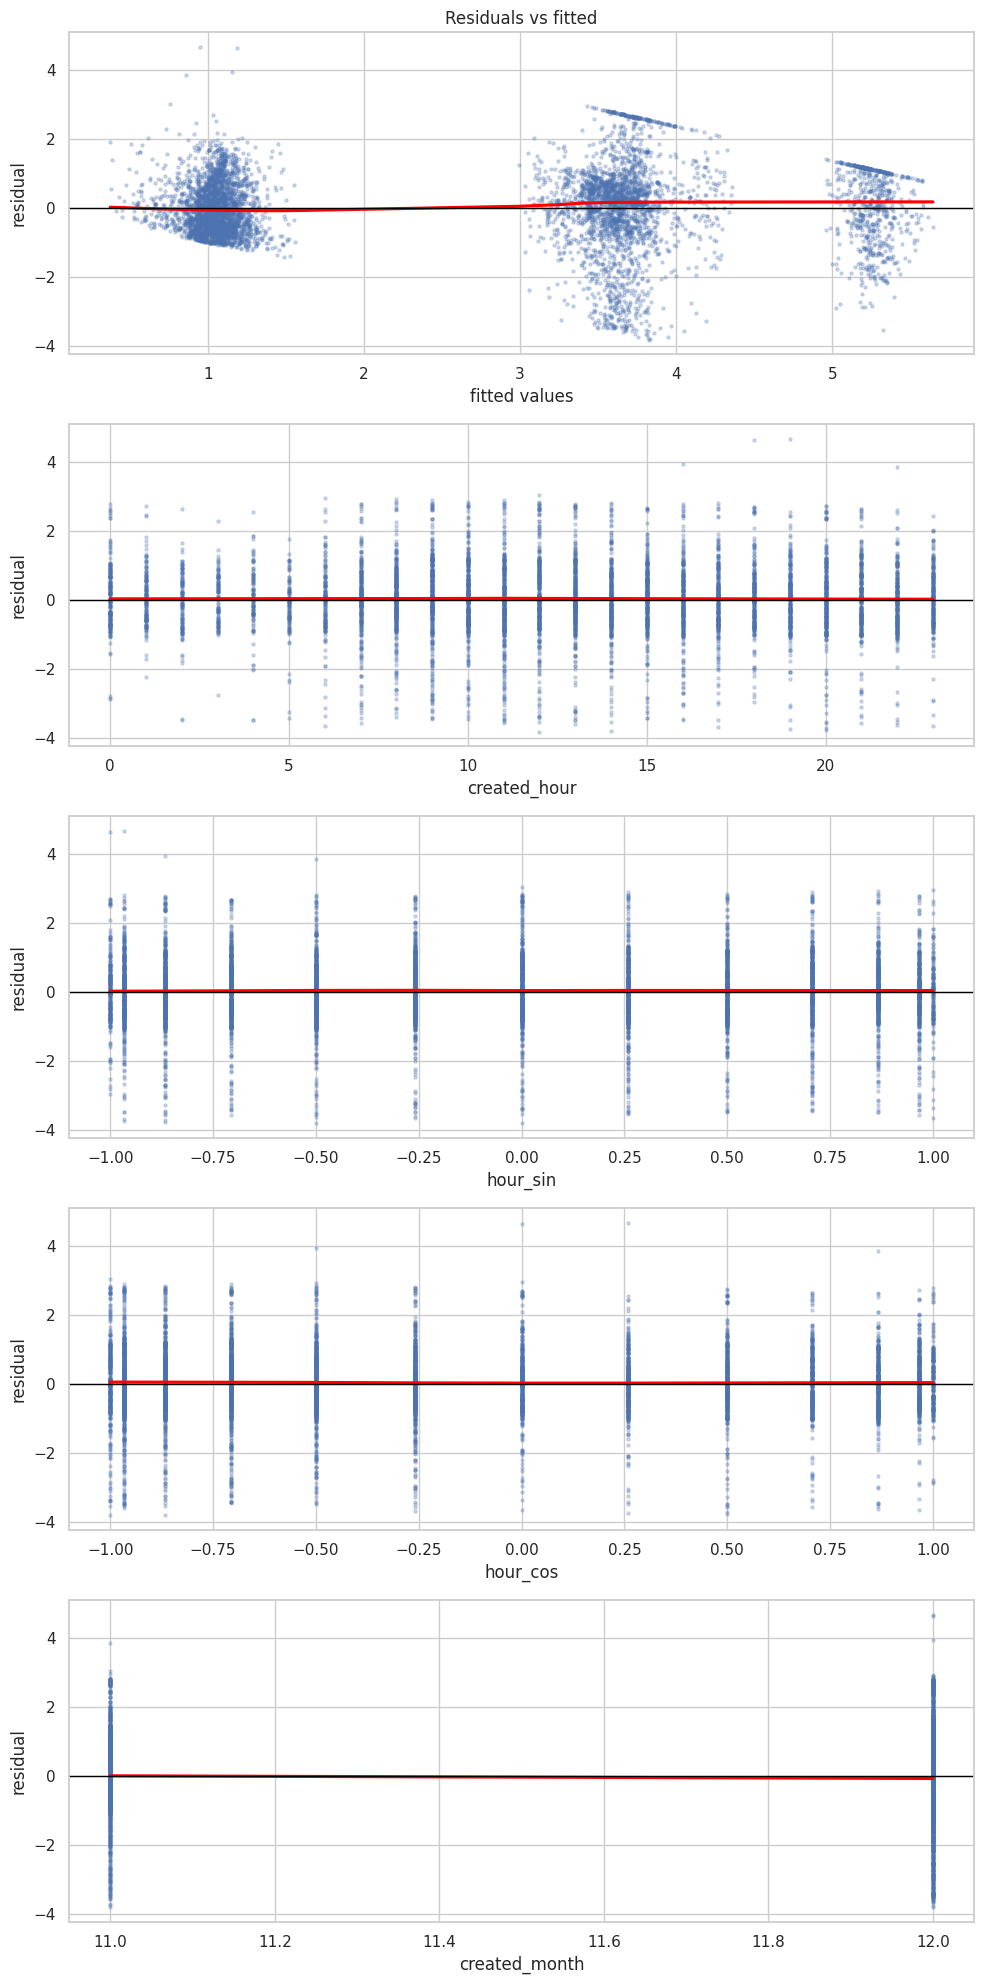

In [14]:
plot_df = df_diag.sample(n=min(PLOT_N, len(df_diag)), random_state=RANDOM_SEED).copy()

LINEARITY_PLOT_COLS = [
    "created_hour",
    "hour_sin",
    "hour_cos",
    "created_month",
]
LINEARITY_PLOT_COLS = [c for c in LINEARITY_PLOT_COLS if c in plot_df.columns]

fig, ax = plt.subplots(len(LINEARITY_PLOT_COLS) + 1, 1, figsize=(10, 4 * (len(LINEARITY_PLOT_COLS) + 1)))

sns.regplot(
    x=plot_df["fitted"],
    y=plot_df["resid"],
    lowess=True,
    scatter_kws={"s": 5, "alpha": 0.25},
    line_kws={"color": "red"},
    ax=ax[0],
)
ax[0].axhline(0, color="black", linewidth=1)
ax[0].set_xlabel("fitted values")
ax[0].set_ylabel("residual")
ax[0].set_title("Residuals vs fitted")

for i, col in enumerate(LINEARITY_PLOT_COLS, start=1):
    sns.regplot(
        x=plot_df[col],
        y=plot_df["resid"],
        lowess=True,
        scatter_kws={"s": 5, "alpha": 0.25},
        line_kws={"color": "red"},
        ax=ax[i],
    )
    ax[i].axhline(0, color="black", linewidth=1)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("residual")

plt.tight_layout()
plt.show()

## 12. Constant variance checks

A funneling residual spread suggests heteroskedasticity and weaker OLS standard-error reliability.

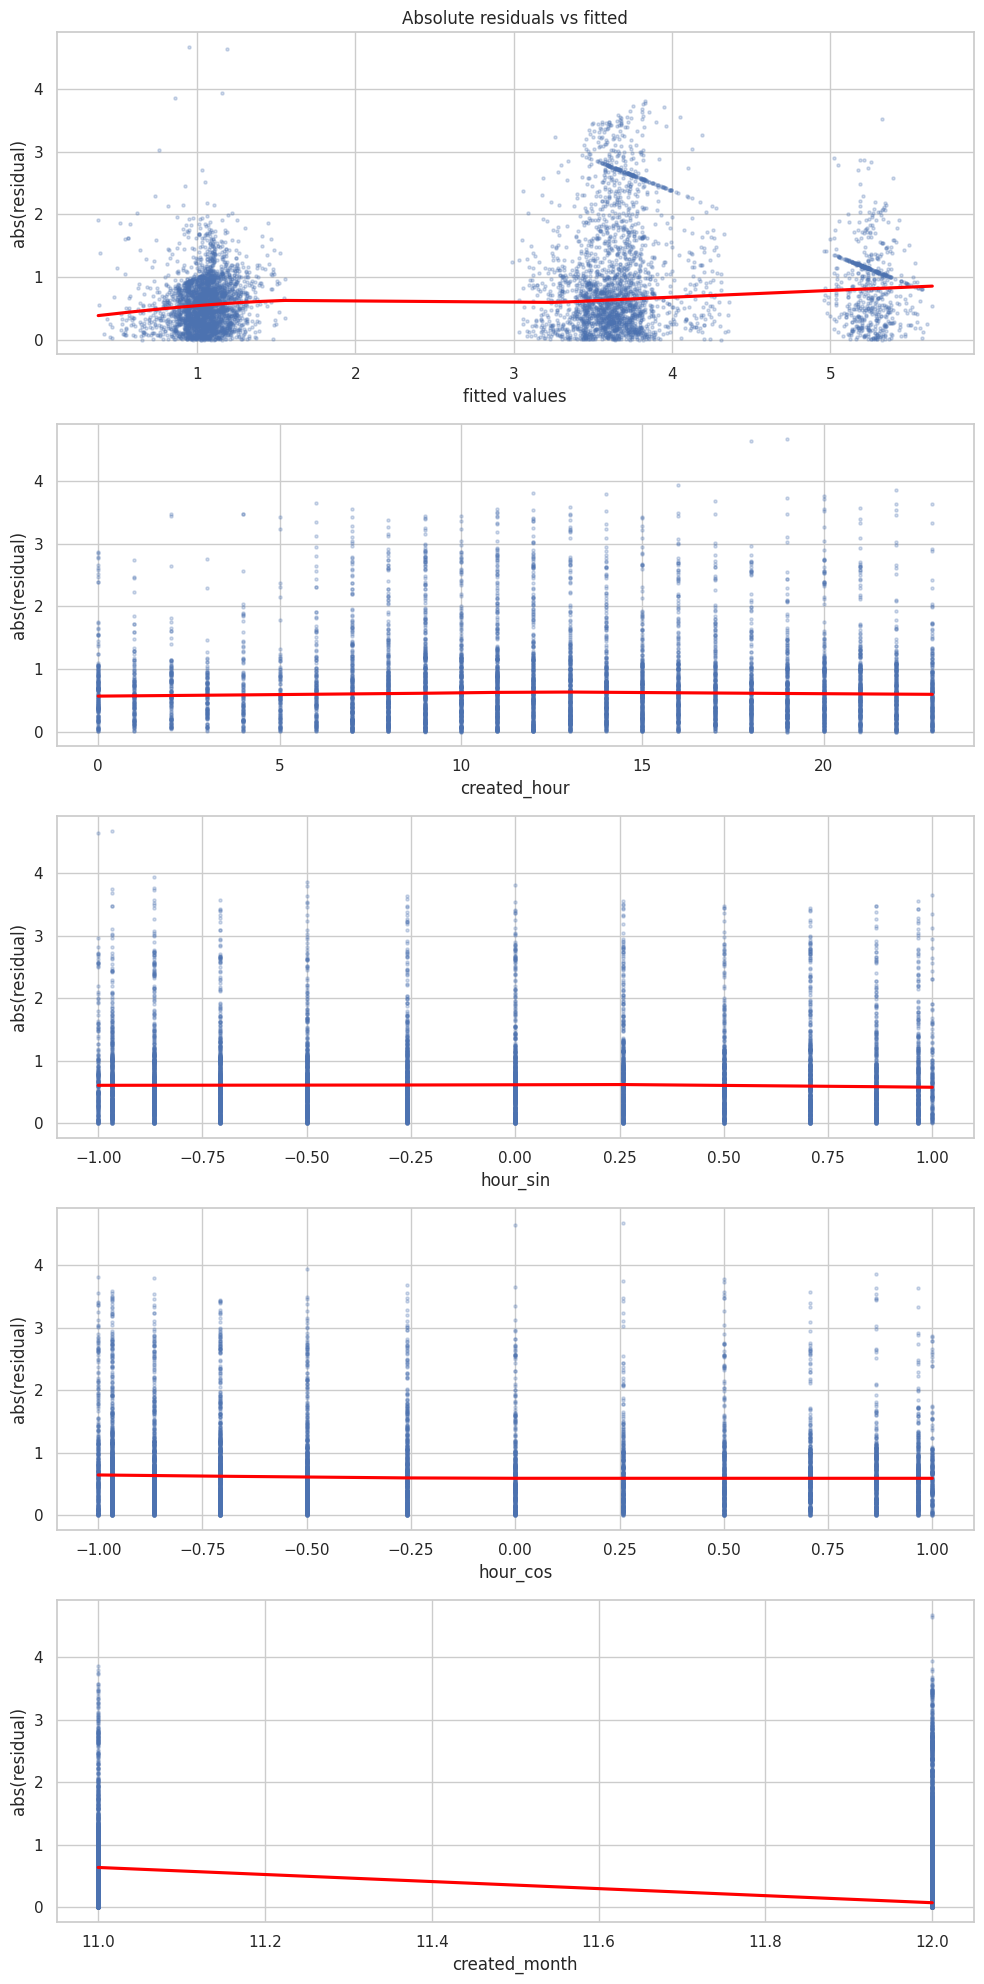

In [15]:
fig, ax = plt.subplots(len(LINEARITY_PLOT_COLS) + 1, 1, figsize=(10, 4 * (len(LINEARITY_PLOT_COLS) + 1)))

sns.regplot(
    x=plot_df["fitted"],
    y=np.abs(plot_df["resid"]),
    lowess=True,
    scatter_kws={"s": 5, "alpha": 0.25},
    line_kws={"color": "red"},
    ax=ax[0],
)
ax[0].set_xlabel("fitted values")
ax[0].set_ylabel("abs(residual)")
ax[0].set_title("Absolute residuals vs fitted")

for i, col in enumerate(LINEARITY_PLOT_COLS, start=1):
    sns.regplot(
        x=plot_df[col],
        y=np.abs(plot_df["resid"]),
        lowess=True,
        scatter_kws={"s": 5, "alpha": 0.25},
        line_kws={"color": "red"},
        ax=ax[i],
    )
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("abs(residual)")

plt.tight_layout()
plt.show()

In [16]:
# Breusch-Pagan test for heteroskedasticity.
# With large data, tiny p-values are common, so still rely on plots for practical importance.
bp_n = min(25_000, len(X))
bp_idx = X.sample(n=bp_n, random_state=RANDOM_SEED).index
bp_stat = het_breuschpagan(results.resid.loc[bp_idx], X.loc[bp_idx])

bp_table = pd.Series(
    bp_stat,
    index=["LM statistic", "LM p-value", "F statistic", "F p-value"],
)
display(bp_table)

LM statistic    7419.990380
LM p-value         0.000000
F statistic      244.957508
F p-value          0.000000
dtype: float64

## 13. Independence / autocorrelation check

Time-ordered residual structure indicates dependence and can bias uncertainty estimates.

Durbin-Watson statistic: 1.9575877848324577
Rule of thumb: near 2 means little first-order autocorrelation; below 2 suggests positive autocorrelation.


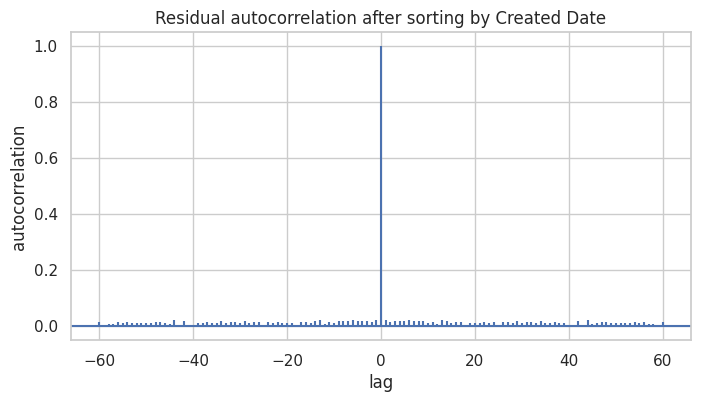

In [17]:
time_diag = df_diag.sort_values("created_dt").copy()
time_resid = time_diag["resid"] - time_diag["resid"].mean()

print("Durbin-Watson statistic:", durbin_watson(time_resid))
print("Rule of thumb: near 2 means little first-order autocorrelation; below 2 suggests positive autocorrelation.")

plt.figure(figsize=(8, 4))
plt.acorr(time_resid.to_numpy(), maxlags=60)
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.title("Residual autocorrelation after sorting by Created Date")
plt.show()

## 14. Normality check using Q-Q plot

Tail deviations in the Q-Q plot indicate non-normal errors, especially relevant for inference at extremes.

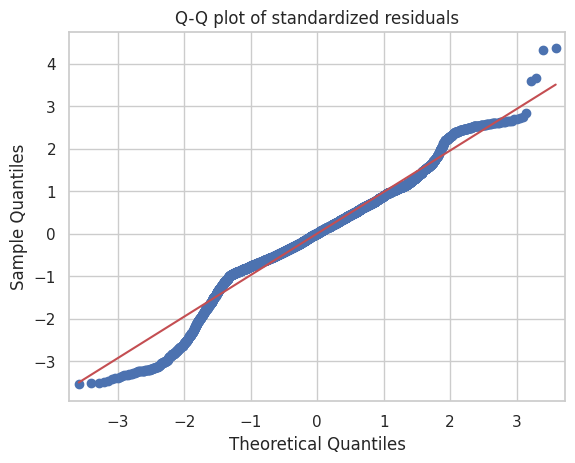

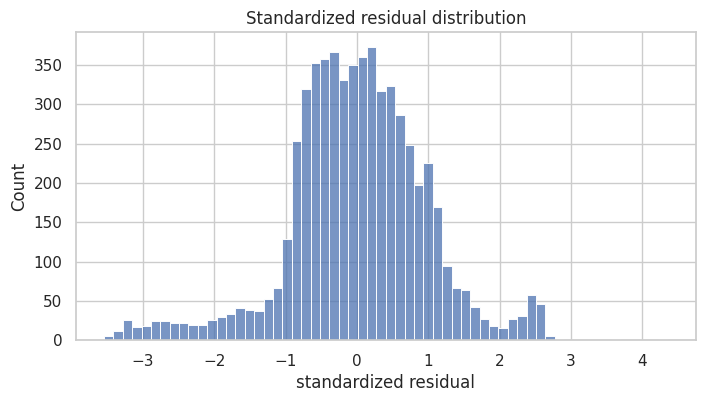

Jarque-Bera statistic: 641.5632469805959
Jarque-Bera p-value: 4.856361664607704e-140
skew: -0.30676425153617737
kurtosis: 4.479809367398443


In [18]:
qq_resid = plot_df["std_resid"].replace([np.inf, -np.inf], np.nan).dropna()

sm.qqplot(qq_resid, line="r")
plt.title("Q-Q plot of standardized residuals")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(qq_resid, bins=60)
plt.xlabel("standardized residual")
plt.title("Standardized residual distribution")
plt.show()

jb_stat, jb_p, skew, kurtosis = sm.stats.jarque_bera(qq_resid)
print("Jarque-Bera statistic:", jb_stat)
print("Jarque-Bera p-value:", jb_p)
print("skew:", skew)
print("kurtosis:", kurtosis)

## 15. Residuals by important categorical features

These plots help check whether region or complaint-type groups still have systematic residual patterns.

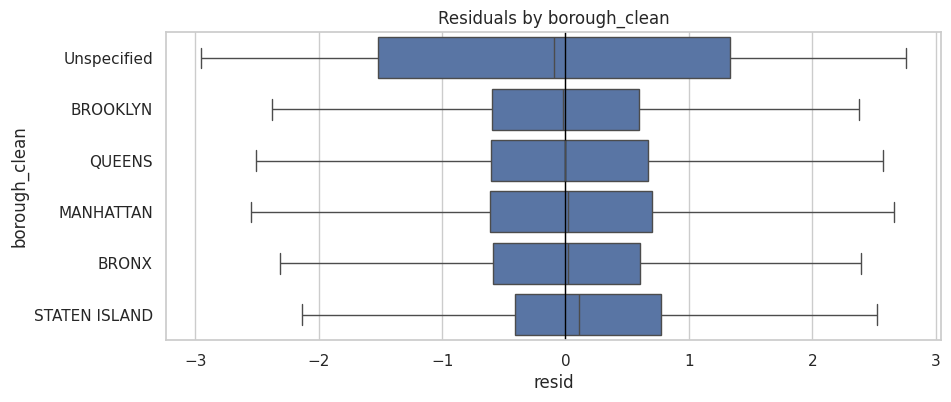

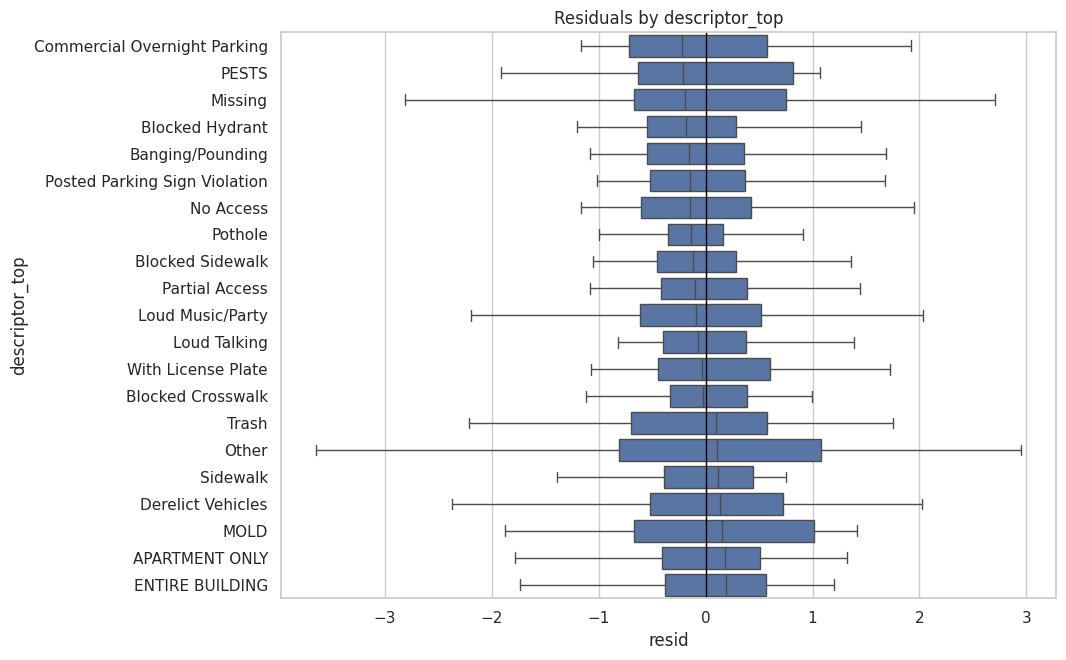

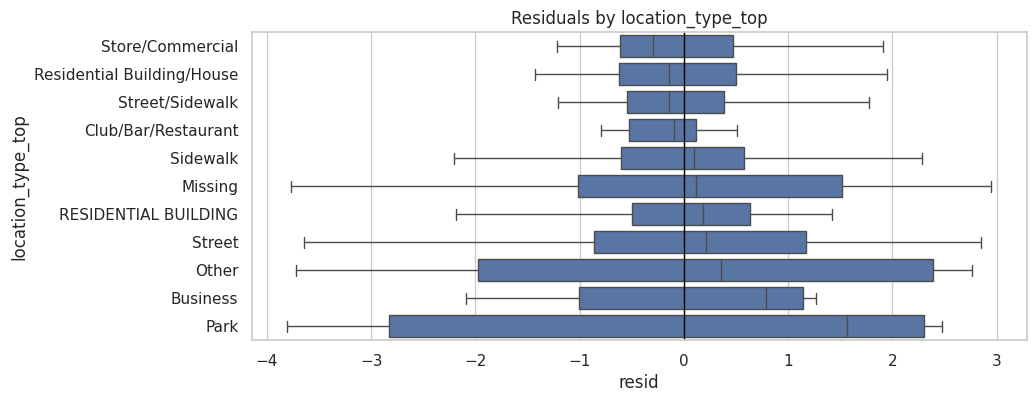

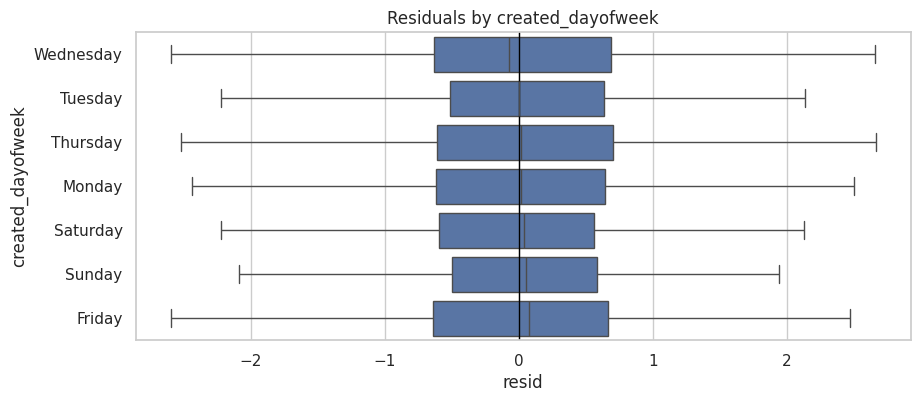

In [19]:
CAT_PLOT_COLS = ["borough_clean", "descriptor_top", "location_type_top", "created_dayofweek"]
CAT_PLOT_COLS = [c for c in CAT_PLOT_COLS if c in plot_df.columns]

for col in CAT_PLOT_COLS:
    order = plot_df.groupby(col)["resid"].median().sort_values().index
    plt.figure(figsize=(10, max(4, 0.35 * len(order))))
    sns.boxplot(data=plot_df, y=col, x="resid", order=order, showfliers=False)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Residuals by {col}")
    plt.show()

## 16. Optional: add simple polynomial terms if LOWESS suggests curvature

If curvature remains strong, adding nonlinear terms can reduce systematic residual patterns.

In [20]:
def fit_with_feature_map(feature_map):
    X_tmp, _, _ = make_design_matrix(df_feat, feature_map)
    res_tmp = sm.OLS(y, X_tmp).fit()
    return res_tmp, X_tmp

feature_map_no_cyclic = {k: dict(v) for k, v in FEATURE_MAP.items()}
feature_map_no_cyclic["hour_cyclic"] = dict(feature_map_no_cyclic["hour_cyclic"])
feature_map_no_cyclic["hour_cyclic"]["enabled"] = False

res_no_cyclic, X_no_cyclic = fit_with_feature_map(feature_map_no_cyclic)

compare = pd.DataFrame({
    "model": ["current", "without_hour_cyclic"],
    "num_predictors_including_const": [X.shape[1], X_no_cyclic.shape[1]],
    "R2": [results.rsquared, res_no_cyclic.rsquared],
    "adj_R2": [results.rsquared_adj, res_no_cyclic.rsquared_adj],
    "AIC": [results.aic, res_no_cyclic.aic],
    "BIC": [results.bic, res_no_cyclic.bic],
})

display(compare)

,model,num_predictors_including_const,R2,adj_R2,AIC,BIC
0,current,44,0.678261,0.677953,134139.761337,134523.179094
1,without_hour_cyclic,42,0.677717,0.677423,134211.810815,134577.800491


## 17. Incremental $R^2$ by feature group

This is a simple variance-explained style check. It fits models by adding feature groups one at a time in the order below. The increments depend on the chosen order, so treat this as exploratory rather than a unique decomposition.

In [21]:
FEATURE_GROUP_ORDER = [
    "descriptor_top",
    "borough_clean",
    "location_type_top",
    "created_dayofweek",
    "created_hour",
    "created_month",
    "hour_cyclic",
]

rows = []
active_map = {k: dict(v, enabled=False) for k, v in FEATURE_MAP.items()}
last_r2 = 0.0

for group in FEATURE_GROUP_ORDER:
    if group not in FEATURE_MAP or not FEATURE_MAP[group].get("enabled", True):
        continue

    active_map[group] = dict(FEATURE_MAP[group], enabled=True)
    X_group, _, _ = make_design_matrix(df_feat, active_map)
    res_group = sm.OLS(y, X_group).fit()

    rows.append({
        "added_group": group,
        "num_columns": X_group.shape[1],
        "R2": res_group.rsquared,
        "incremental_R2": res_group.rsquared - last_r2,
        "adj_R2": res_group.rsquared_adj,
    })
    last_r2 = res_group.rsquared

r2_decomp = pd.DataFrame(rows)
display(r2_decomp)

,added_group,num_columns,R2,incremental_R2,adj_R2
0,descriptor_top,20,0.495823,0.495823,0.495610
1,borough_clean,25,0.500700,0.004876,0.500433
2,location_type_top,34,0.676953,0.176254,0.676716
3,created_dayofweek,40,0.677085,0.000132,0.676805
4,created_hour,41,0.677499,0.000414,0.677212
5,created_month,42,0.677717,0.000218,0.677423
6,hour_cyclic,44,0.678261,0.000544,0.677953


## 18. Standardized coefficients for numeric predictors

For categorical dummy variables, coefficients are relative to omitted baseline categories. For numeric predictors, standardizing helps compare effect sizes more directly.

In [22]:
num_cols = []
for group, spec in FEATURE_MAP.items():
    if spec.get("enabled", True) and spec["type"] == "num":
        num_cols.extend([c for c in spec["columns"] if c in df_feat.columns])

if num_cols:
    X_num = df_feat[num_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_num_std = (X_num - X_num.mean()) / X_num.std(ddof=0).replace(0, 1)
    X_num_std = sm.add_constant(X_num_std, has_constant="add")

    std_results = sm.OLS(y, X_num_std).fit()
    print(std_results.summary())
else:
    print("No numeric predictors are enabled.")

                            OLS Regression Results                            
Dep. Variable:              log_delay   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     448.4
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        17:56:14   Log-Likelihood:                -91652.
No. Observations:               44983   AIC:                         1.833e+05
Df Residuals:                   44978   BIC:                         1.834e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.5692      0.009    293.543

## 19. Final quick checklist

Use the outputs above to check:

1. **Linearity:** residual LOWESS curves should be roughly flat.
2. **Constant variance:** absolute residual LOWESS curves should not show strong funneling.
3. **Independence:** autocorrelation should not be too strong; Durbin-Watson near 2 is better.
4. **Normality:** Q-Q plot should not have extreme tail deviations, though large datasets often reject exact normality.
5. **Model usefulness:** train/test $R^2$ should not collapse relative to in-sample $R^2$.